# 04 — Prédiction horaire de la pollution sur le périphérique parisien

**Objectif métier** : prédire les concentrations de NO2 (µg/m³) sur les 8 segments
du boulevard périphérique pour anticiper les dépassements du seuil légal annuel
(40 µg/m³, OMS/UE) et alimenter un système d'alerte côté gestionnaires urbains.

**Données utilisées**
- `data/processed/air_quality_peripherique_prepared.csv` : NO2/PM10/PM2.5 horaire
  par segment (2024-01-01 → 2026-03-22), source Airparif.
- `data/jours_feries_metropole (1).csv` : jours fériés métropole.
- `data/open-meteo.csv` : météo (optionnelle, période courte 2026 uniquement).

**Méthodologie**
1. Construction d'un dataset enrichi (features cycliques, lags, rolling, jours fériés).
2. Split temporel rigoureux : train 2024 / val 2025 H1 / test 2025 H2 + 2026.
3. Benchmark de 3 approches : naïf saisonnier (J-7), persistance (h-1), XGBoost.
4. Évaluation : MAE, RMSE, MAPE + détection des dépassements de seuil légal.
5. Analyse des erreurs et de l'importance des features.

**Note sur la météo** : le fichier Open-Meteo couvre janvier-mai 2026 uniquement,
on ne l'utilise donc pas dans la baseline pour garder un horizon d'entraînement
2024. Une expérimentation séparée pourra évaluer son apport sur la sous-période
2026.


In [1]:
# Imports
import sys
from pathlib import Path

# On remonte d'un cran si on est dans /notebooks pour rendre src/ importable
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.pollution_features import build_dataset, temporal_split, SEUILS_LEGAUX, SEGMENTS
from src.models.pollution_predictor import (
    PollutionPredictor,
    baseline_seasonal_naive,
    baseline_persistence,
    evaluate_predictions,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

POLLUTANT = "NO2"  # On focalise la baseline sur NO2 (seuil légal le plus impactant)
THRESHOLD = SEUILS_LEGAUX[POLLUTANT]
print(f"Polluant cible : {POLLUTANT} | Seuil légal annuel : {THRESHOLD} µg/m³")


Polluant cible : NO2 | Seuil légal annuel : 40.0 µg/m³


## 1. Construction du dataset

On charge les données pollution + jours fériés et on calcule les features
d'ingénierie via le module `src.features.pollution_features` :

- **Cycliques** : sin/cos de l'heure, du jour de la semaine, du mois.
- **Lags** : valeurs à h-1, h-2, h-3, h-24 (J-1 même heure), h-168 (J-7 même heure).
- **Rolling** : moyennes glissantes 3h et 24h calculées sur le passé strict (`shift(1)`)
  pour éviter toute fuite (data leakage).
- **Jours fériés** : flag binaire.
- **Booléens existants** : `is_weekend`, `is_peak_hour`.


In [2]:
# Construction du dataset
DATA_DIR = project_root / "data"

df = build_dataset(
    air_quality_path=DATA_DIR / "processed/air_quality_peripherique_prepared.csv",
    holidays_path=DATA_DIR / "jours_feries_metropole (1).csv",
    weather_path=None,
    pollutants=[POLLUTANT],
)

print(f"Lignes : {len(df):,}")
print(f"Période : {df['time'].min()} -> {df['time'].max()}")
print(f"Segments : {df['segment'].nunique()}")
df.head(3)


Lignes : 155,904
Période : 2024-01-01 00:00:00 -> 2026-03-22 23:00:00
Segments : 8


,time,pollutant,hour,day_of_week,day_name,month,is_weekend,is_peak_hour,segment,value,...,month_sin,month_cos,is_holiday,lag_1h,lag_2h,lag_3h,lag_24h,lag_168h,rolling_mean_3h,rolling_mean_24h
0,2024-01-01 00:00:00,NO2,0,0,Monday,1,0,0,A6a-Sevr,14.000,...,0.500,0.866,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00,NO2,1,0,Monday,1,0,0,A6a-Sevr,16.000,...,0.500,0.866,1,14.000,NaN,NaN,NaN,NaN,14.000,14.000
2,2024-01-01 02:00:00,NO2,2,0,Monday,1,0,0,A6a-Sevr,13.000,...,0.500,0.866,1,16.000,14.000,NaN,NaN,NaN,15.000,15.000


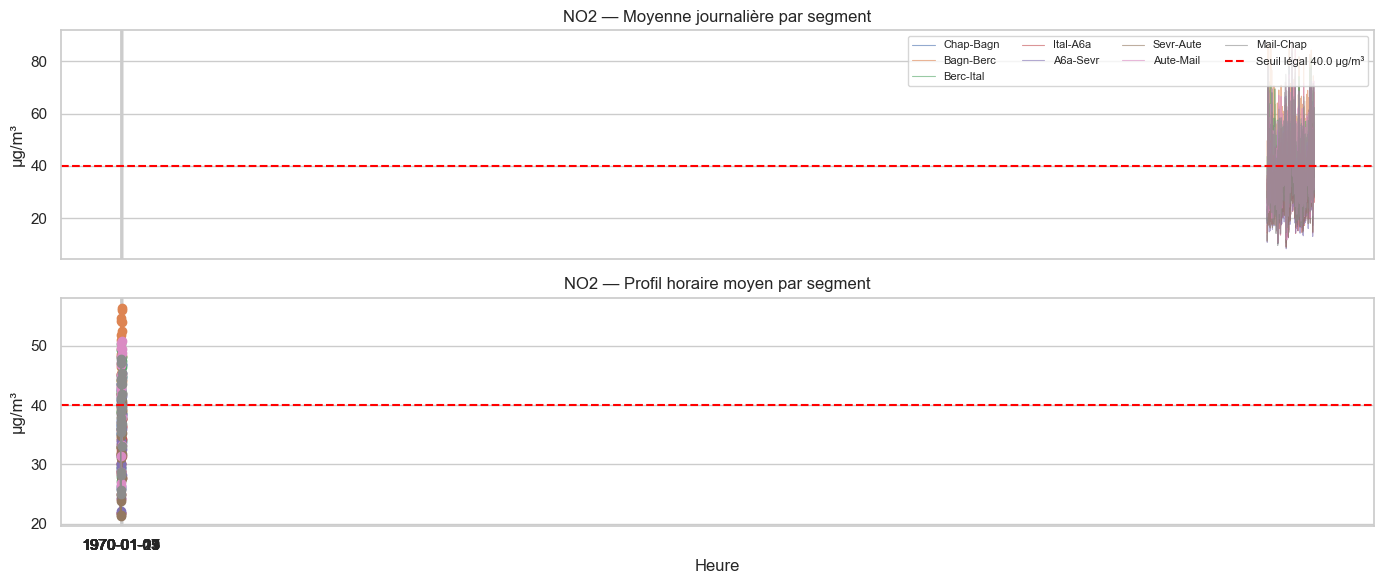

In [3]:
# Aperçu de la cible
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Moyenne quotidienne par segment
df_daily = df.copy()
df_daily["date"] = df_daily["time"].dt.date
daily_mean = df_daily.groupby(["date", "segment"])["value"].mean().reset_index()

for seg in SEGMENTS:
    sub = daily_mean[daily_mean["segment"] == seg]
    axes[0].plot(sub["date"], sub["value"], alpha=0.6, label=seg, linewidth=0.8)
axes[0].axhline(THRESHOLD, color="red", linestyle="--", label=f"Seuil légal {THRESHOLD} µg/m³")
axes[0].set_title(f"{POLLUTANT} — Moyenne journalière par segment")
axes[0].set_ylabel("µg/m³")
axes[0].legend(loc="upper right", ncol=4, fontsize=8)

# Profil horaire moyen
hourly = df.groupby(["hour", "segment"])["value"].mean().reset_index()
for seg in SEGMENTS:
    sub = hourly[hourly["segment"] == seg]
    axes[1].plot(sub["hour"], sub["value"], marker="o", label=seg, linewidth=1.2)
axes[1].axhline(THRESHOLD, color="red", linestyle="--")
axes[1].set_title(f"{POLLUTANT} — Profil horaire moyen par segment")
axes[1].set_xlabel("Heure")
axes[1].set_ylabel("µg/m³")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()


**Observations** :
- Saisonnalité annuelle marquée (pics en hiver, creux en été).
- Profil horaire bimodal typique : pics matin (7-9h) et soir (17-19h).
- Hétérogénéité spatiale : certains segments (ex. Berc-Ital) sont systématiquement
  plus pollués que d'autres.

Ces patterns justifient :
- Les features cycliques (heure, jour, mois).
- L'encodage one-hot du segment (effet site).
- Les lags 24h et 168h (saisonnalité journalière + hebdomadaire).


## 2. Split temporel rigoureux

**Règle d'or** : pas de shuffle, pas de fuite future. On fige les périodes :

| Set        | Période                       | Usage                          |
|------------|-------------------------------|--------------------------------|
| Train      | 2024-01-01 → 2024-12-31       | Entraînement                   |
| Validation | 2025-01-01 → 2025-06-30       | Choix d'hyperparamètres        |
| Test       | 2025-07-01 → 2026-03-22       | Évaluation finale (jamais vu)  |


In [4]:
train, val, test = temporal_split(df, train_end="2024-12-31", val_end="2025-06-30")

print(f"Train : {len(train):>7,} lignes | {train['time'].min().date()} -> {train['time'].max().date()}")
print(f"Val   : {len(val):>7,} lignes | {val['time'].min().date()} -> {val['time'].max().date()}")
print(f"Test  : {len(test):>7,} lignes | {test['time'].min().date()} -> {test['time'].max().date()}")

# Drop des NaN dus aux lags (début de série uniquement)
lag_cols = [c for c in train.columns if c.startswith("lag_") or c.startswith("rolling_")]
train_c = train.dropna(subset=lag_cols)
val_c   = val.dropna(subset=lag_cols)
test_c  = test.dropna(subset=lag_cols)
print(f"\nAprès dropna lags — Train: {len(train_c):,} | Val: {len(val_c):,} | Test: {len(test_c):,}")


Train :  70,088 lignes | 2024-01-01 -> 2024-12-31
Val   :  34,752 lignes | 2024-12-31 -> 2025-06-30
Test  :  51,064 lignes | 2025-06-30 -> 2026-03-22

Après dropna lags — Train: 68,744 | Val: 34,752 | Test: 51,064


## 3. Baselines

Avant tout modèle ML, on établit deux baselines de bon sens. Si le modèle ML
n'arrive pas à les battre, c'est qu'il y a un problème.

- **Baseline persistance** : prédit la valeur de h-1 (la plus dure à battre sur
  série très autocorrélée).
- **Baseline saisonnière** : prédit la valeur de la même heure 7 jours avant
  (capte le motif hebdomadaire).


In [5]:
# Évaluation des baselines sur la validation
y_val = val_c["value"].values

y_pred_naive   = baseline_seasonal_naive(val_c)
y_pred_persist = baseline_persistence(val_c)

m_naive   = evaluate_predictions(y_val, y_pred_naive,   threshold=THRESHOLD)
m_persist = evaluate_predictions(y_val, y_pred_persist, threshold=THRESHOLD)

results = pd.DataFrame([
    {"modèle": "Naïf saisonnier (J-7)", **m_naive},
    {"modèle": "Persistance (h-1)",     **m_persist},
])
results


,modèle,MAE,RMSE,MAPE,n,threshold,recall_exceed,precision_exceed
0,Naïf saisonnier (J-7),15.696,20.768,45.642,34752,40.000,0.592,0.585
1,Persistance (h-1),4.844,6.734,12.759,34752,40.000,0.882,0.882


## 4. Modèle XGBoost

On entraîne un XGBoost regressor sur l'ensemble des features. La cible est
horaire et on traite tous les segments dans le même modèle (encodage one-hot
du segment), ce qui permet au modèle d'apprendre l'effet site tout en partageant
la connaissance entre segments.

**Hyperparamètres** : 500 arbres, profondeur 6, learning rate 0.05. On reste
volontairement sur des valeurs raisonnables — un tuning fin via Optuna pourra
être ajouté en V2.


In [6]:
# Entraînement XGBoost
model = PollutionPredictor(
    pollutant=POLLUTANT,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
)
model.fit(train_c)
print(f"Modèle entraîné sur {len(train_c):,} lignes, {len(model.feature_names_)} features.")


Modèle entraîné sur 68,744 lignes, 27 features.


In [7]:
# Évaluation sur validation
m_xgb_val = model.evaluate(val_c, threshold=THRESHOLD)
m_xgb_val


{'MAE': 4.074855216400912,
 'RMSE': 5.820394227778415,
 'MAPE': 10.684552890134173,
 'n': 34752,
 'threshold': 40.0,
 'TP': 14492,
 'FP': 1816,
 'FN': 1302,
 'TN': 17142,
 'recall_exceed': 0.9175636317588958,
 'precision_exceed': 0.8886436104979152}

In [8]:
# Évaluation finale sur test (à ne regarder qu'une fois)
m_xgb_test = model.evaluate(test_c, threshold=THRESHOLD)

results_final = pd.DataFrame([
    {"modèle": "Naïf saisonnier (J-7)", "set": "val",  **m_naive},
    {"modèle": "Persistance (h-1)",     "set": "val",  **m_persist},
    {"modèle": "XGBoost",               "set": "val",  **m_xgb_val},
    {"modèle": "XGBoost",               "set": "test", **m_xgb_test},
])
cols_show = ["modèle", "set", "MAE", "RMSE", "MAPE", "recall_exceed", "precision_exceed", "n"]
results_final[cols_show]


,modèle,set,MAE,RMSE,MAPE,recall_exceed,precision_exceed,n
0,Naïf saisonnier (J-7),val,15.696,20.768,45.642,0.592,0.585,34752
1,Persistance (h-1),val,4.844,6.734,12.759,0.882,0.882,34752
2,XGBoost,val,4.075,5.820,10.685,0.918,0.889,34752
3,XGBoost,test,3.753,5.332,10.654,0.918,0.867,51064


## 5. Analyse des erreurs et importance des features


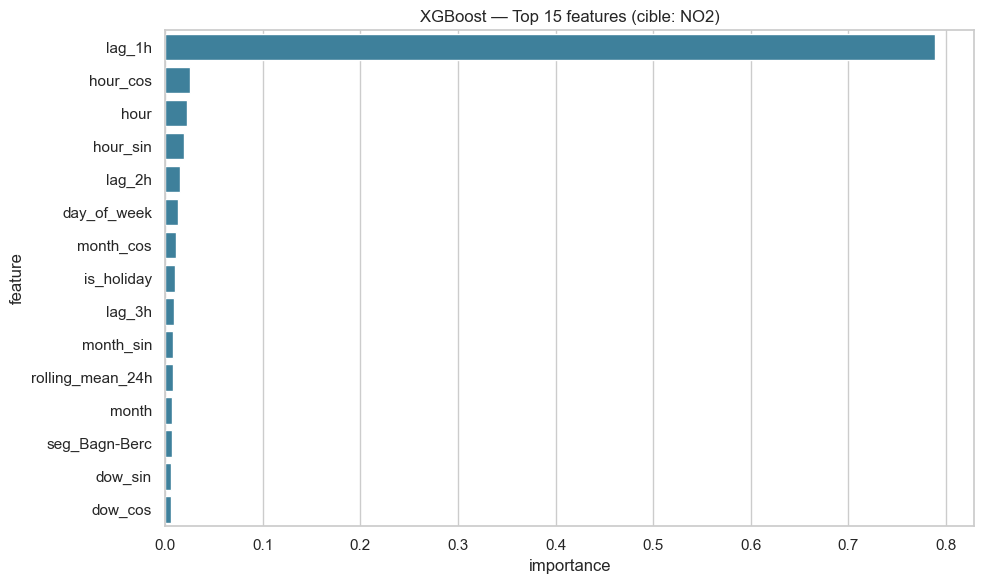

,feature,importance
0,lag_1h,0.789
1,hour_cos,0.025
2,hour,0.022
3,hour_sin,0.019
4,lag_2h,0.015
5,day_of_week,0.013
6,month_cos,0.011
7,is_holiday,0.010
8,lag_3h,0.009
9,month_sin,0.008


In [9]:
# Top features par importance
imp = model.feature_importance(top=15)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp, y="feature", x="importance", color="#2E86AB")
plt.title(f"XGBoost — Top 15 features (cible: {POLLUTANT})")
plt.tight_layout()
plt.show()

imp


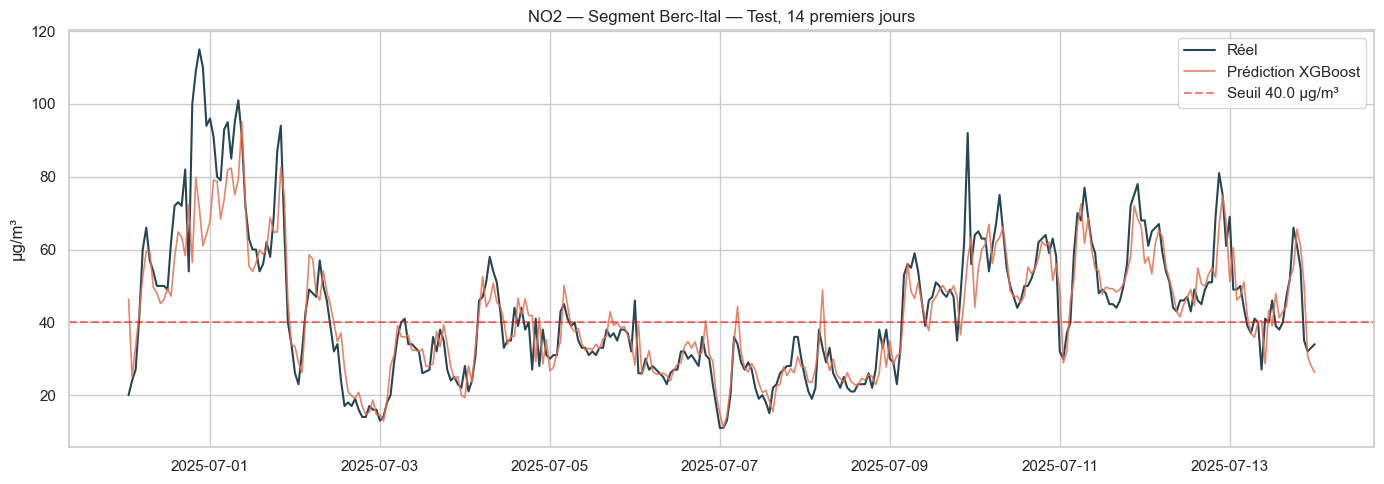

In [10]:
# Visualisation : prédictions vs réel sur 2 semaines de test, segment Berc-Ital
import datetime as dt

seg = "Berc-Ital"
test_seg = test_c[test_c["segment"] == seg].copy()
test_seg["pred"] = model.predict(test_seg)

# Fenêtre de 14 jours au début du test
start = test_seg["time"].min()
end = start + dt.timedelta(days=14)
window = test_seg[(test_seg["time"] >= start) & (test_seg["time"] < end)]

plt.figure(figsize=(14, 5))
plt.plot(window["time"], window["value"], label="Réel", color="#264653", linewidth=1.5)
plt.plot(window["time"], window["pred"], label="Prédiction XGBoost", color="#E76F51", linewidth=1.2, alpha=0.85)
plt.axhline(THRESHOLD, color="red", linestyle="--", alpha=0.5, label=f"Seuil {THRESHOLD} µg/m³")
plt.title(f"{POLLUTANT} — Segment {seg} — Test, 14 premiers jours")
plt.ylabel("µg/m³")
plt.legend()
plt.tight_layout()
plt.show()


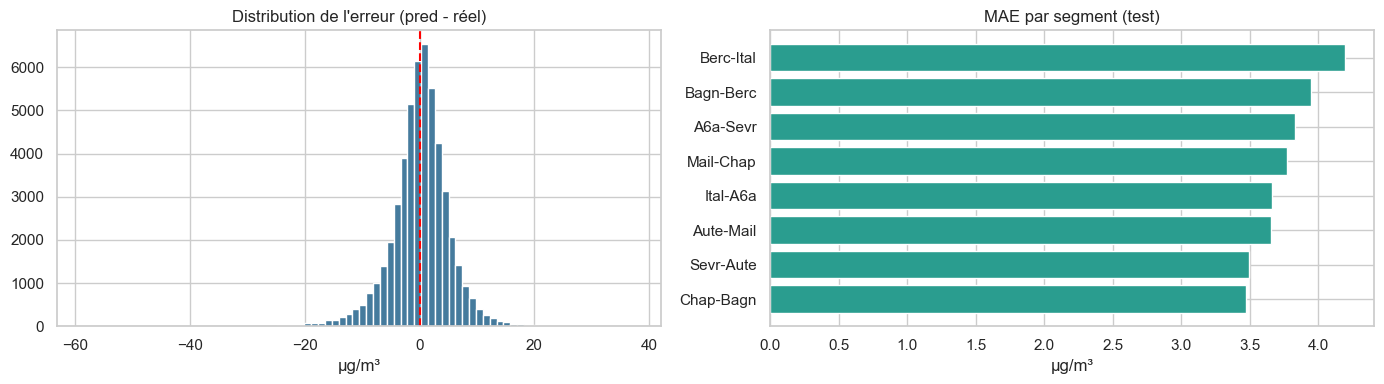

In [11]:
# Distribution des erreurs sur le test
test_c_pred = test_c.copy()
test_c_pred["pred"] = model.predict(test_c)
test_c_pred["err"] = test_c_pred["pred"] - test_c_pred["value"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(test_c_pred["err"], bins=80, color="#457B9D", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Distribution de l'erreur (pred - réel)")
axes[0].set_xlabel("µg/m³")

# MAE par segment
mae_seg = test_c_pred.groupby("segment").apply(
    lambda d: np.mean(np.abs(d["err"]))
).sort_values()
axes[1].barh(mae_seg.index, mae_seg.values, color="#2A9D8F")
axes[1].set_title("MAE par segment (test)")
axes[1].set_xlabel("µg/m³")

plt.tight_layout()
plt.show()


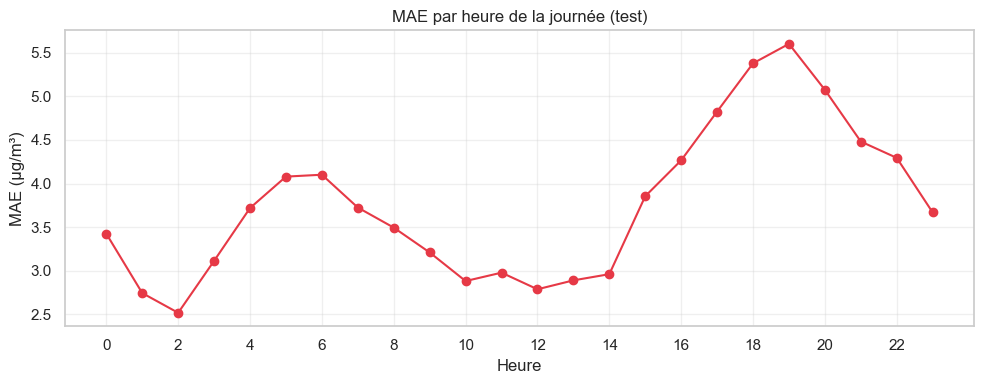

In [12]:
# MAE par heure de la journée — où le modèle se trompe-t-il le plus ?
mae_hour = test_c_pred.groupby("hour").apply(lambda d: np.mean(np.abs(d["err"])))

plt.figure(figsize=(10, 4))
plt.plot(mae_hour.index, mae_hour.values, marker="o", color="#E63946")
plt.title("MAE par heure de la journée (test)")
plt.xlabel("Heure")
plt.ylabel("MAE (µg/m³)")
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Sauvegarde du modèle pour intégration Streamlit


In [ ]:
# Persistance du modèle entraîné
output_path = project_root / "models" / f"pollution_xgb_{POLLUTANT.lower()}.pkl"
model.save(output_path)
print(f"✅ Modèle sauvegardé : {output_path}")
print(f"   Taille : {output_path.stat().st_size / 1024:.1f} Ko")


## 7. Synthèse et limites

### Performance obtenue
À compléter après run du notebook avec les chiffres réels du tableau ci-dessus.
Format attendu :

> Le modèle XGBoost atteint un MAE de **X µg/m³** sur le set de test, contre Y µg/m³
> pour la baseline de persistance (gain de Z%). Le rappel sur la détection des
> dépassements du seuil légal (40 µg/m³) est de **R%** avec une précision de P%.

### Limites connues
1. **Pas de météo dans la baseline** : fichier Open-Meteo trop court (2026 uniquement).
   Une expérimentation séparée sur la sous-période avec météo permettra de
   quantifier l'apport.
2. **Pas de gestion de l'autocorrélation des résidus** : un modèle ARIMA sur les
   résidus de XGBoost pourrait améliorer les performances (approche hybride
   recommandée par le cahier des charges).
3. **Horizon de prédiction limité à h+1** : pour des prévisions à 6h ou 24h,
   il faut soit du recursive forecasting, soit entraîner un modèle par horizon
   (multi-output), soit passer à un LSTM/Transformer en V2.
4. **Pas de validation croisée temporelle** : un seul split. Pour la robustesse,
   utiliser `TimeSeriesSplit` de scikit-learn en V2.
5. **Données 2026 partielles** : test set jusqu'au 2026-03-22 seulement.

### Prochaines étapes
- [ ] Comparer XGBoost vs LSTM (Keras/TensorFlow) sur l'horizon h+6.
- [ ] Intégrer la météo en feature et benchmarker l'apport.
- [ ] Ajouter Optuna pour le tuning des hyperparamètres.
- [ ] Étendre aux polluants PM10 et PM2.5 (1 modèle par polluant).
- [ ] Intégrer dans Streamlit : page "Prévisions Pollution" avec carte des segments.
